# Import the libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.metrics import classification_report

import warnings
warnings.filterwarnings('ignore')

# Create a Classification dataset

In [2]:
X, y = make_classification(n_samples=100, n_features=2, n_informative=1, n_redundant=0, n_classes=2, n_clusters_per_class=1, random_state=41, hypercube=False, class_sep=20)

# Scatter Plot of the data

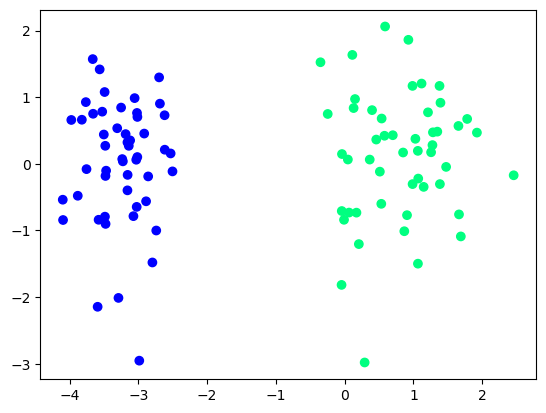

In [3]:
plt.scatter(X[:,0], X[:,1],c=y, cmap='winter');

# Train Test split

In [4]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [5]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((80, 2), (20, 2), (80,), (20,))

# Using SGDClassifier

In [6]:
sgd = SGDClassifier(loss='log_loss', penalty=None, max_iter=1000, eta0=0.5, learning_rate='constant', random_state=42)

## Fit the model

In [7]:
sgd.fit(X_train, y_train)

SGDClassifier(eta0=0.5, learning_rate='constant', loss='log_loss', penalty=None,
              random_state=42)

## Coefficients and Intercept

In [8]:
print(f'Intercept: ', sgd.intercept_)
print(f'Coefficients: ', sgd.coef_)

Intercept:  [4.18167764]
Coefficients:  [[3.68447414 0.09467783]]


In [9]:
# aX + bY + c = 0 => y = (-a/b)X + (-c/b)
m1 = - (sgd.coef_[0][0] / sgd.coef_[0][1])
b1 = - (sgd.intercept_ / sgd.coef_[0][1])

In [10]:
x_input = np.linspace(-3,3,100)
y_input = m1 * x_input + b1

# Using Stochastic Gradient Descent

In [11]:
class MyLOR:

    def __init__(self, lr, epochs=1000):
        self.coef_ = None
        self.intercept_ = None
        self.lr = lr
        self.epochs = epochs

    def sigmoid(self, z):
        return 1 / (1 + np.exp(-z))

    def fit(self, X_train, y_train):
        
        # Add 1 before X (insert 1's at 0th index in X_train)
        X_train = np.insert(X_train, 0, 1, axis=1)

        # Initialize the coefficents/weights matrix with zeros
        betas = np.ones(X_train.shape[1])

        for i in range(self.epochs):
            for j in range(X_train.shape[0]):

                # Generate a random number to select a row from the training dataset
                idx = np.random.randint(0, X_train.shape[0])
                
                # y_hat = sigmoid(summation of Xi and beta i)
                y_hat = self.sigmoid(np.dot(X_train[idx], betas))
    
                # Calculate the update term
                betas = betas + self.lr * (np.dot((y_train[idx] - y_hat), X_train[idx]))
    
        # Calculate Intercept and coefficents
        self.intercept_ = betas[0]
        self.coef_ = betas[1:]

    def predict_proba(self, X_test):
        z = np.dot(X_test, self.coef_) + self.intercept_
        return self.sigmoid(z)

    def predict(self, X_test):
        return (self.predict_proba(X_test) >= 0.5).astype(int)

## Fit the model

In [12]:
mylor = MyLOR(lr=0.5, epochs=1000)

In [13]:
mylor.fit(X_train, y_train)

## Coefficients and Intercept

In [14]:
print(f'Intercept: ', mylor.intercept_)
print(f'Coefficients: ', mylor.coef_)

Intercept:  8.84540673015784
Coefficients:  [6.91246583 0.42831921]


In [15]:
m2 = - (mylor.coef_[0] / mylor.coef_[1])
b2 = - (mylor.intercept_ / mylor.coef_[1])

In [16]:
x_input1 = np.linspace(-3,3,100)
y_input1 = m2 * x_input1 + b2

# Decision Boundary - Scikit Learn's SGDClassifier vs Stochastic Gradient Descent Logistic Regression

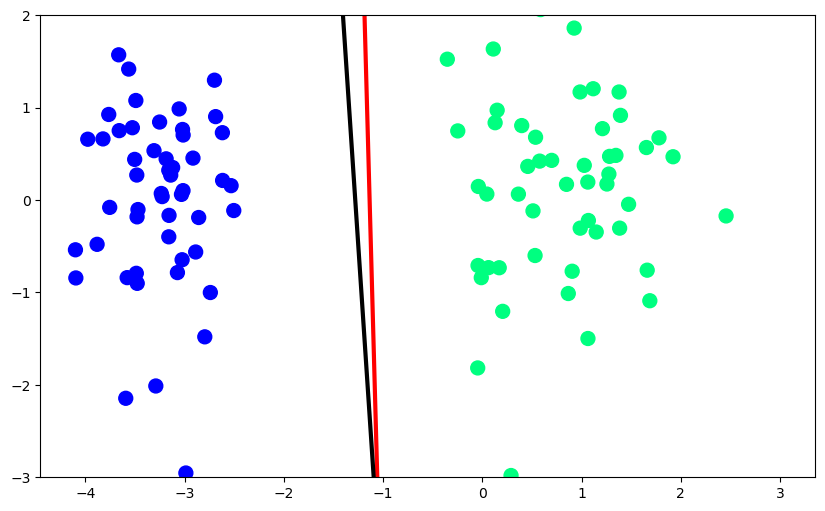

In [17]:
plt.figure(figsize=(10,6))
plt.plot(x_input, y_input, color='red', linewidth=3)
plt.plot(x_input1, y_input1, color='black', linewidth=3)
plt.scatter(X[:,0], X[:,1], c=y,cmap='winter', s=100)
plt.ylim(-3,2);